# Replicating *Learning Undirected Graphs in Financial Markets*
**Cardoso & Palomar (2020) · arXiv:2005.09958v4**

---

This notebook reproduces all four main experiments from the paper. The core idea: given a matrix of asset log-returns, learn a **graph Laplacian** $L$ that encodes the conditional dependency structure among assets under a Gaussian Markov Random Field (GMRF) model. An edge between two stocks means they are conditionally correlated given all others.

| Figure | Experiment | Data | Core method |
|--------|-----------|------|-------------|
| **Fig 1** | Effect of preprocessing choices | 97 S&P 500 stocks, 3 sectors, 2016–2019 | Base GMRF solver |
| **Fig 2** | Degree control: Algorithm 1 vs SGL | Same 97 stocks | Algorithm 1 (proposed) vs SGL baseline |
| **Fig 3** | Time-varying connectivity signal | FAAMUNG 7 stocks, 2019–2020 | Algorithm 2 (rolling windows) |
| **Fig 4** | Connectivity-gated trading strategy | FAAMUNG 7 stocks, 2019–2020 | $\lambda_2$ threshold signal |

## 0. Environment Setup

In [1]:
import os, sys

# Resolve paths relative to the project root
PROJECT_ROOT = '/Users/jash/Financial_networks_project'
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display, Code
import inspect

plt.rcParams['figure.dpi'] = 110
print('Setup complete. CWD:', os.getcwd())

Setup complete. CWD: /Users/jash/Financial_networks_project


---

## 1. Mathematical Foundation

### 1.1 The GMRF Laplacian Estimation Problem

The paper frames graph learning as penalized maximum-likelihood estimation of the precision matrix $\Theta = L$, where $L$ is constrained to be a **graph Laplacian**:

$$\underset{L}{\text{minimize}} \quad \text{tr}(LS) - \log \text{gdet}(L) + \beta \sum_{i < j} |L_{ij}|$$

$$\text{subject to} \quad L\mathbf{1} = 0, \quad L_{ij} \leq 0 \;(i \neq j), \quad L \succeq 0$$

where:
- $S$ is the **sample correlation matrix** (not covariance — see Fig 1)
- $\text{gdet}(L) = \prod_{\lambda_i > 0} \lambda_i$ is the **pseudo-determinant** (product of positive eigenvalues; plain $\det = 0$ since $L$ is singular)
- $\beta$ is the sparsity regularizer

### 1.2 Laplacian Properties

| Property | Meaning |
|----------|---------|
| **P1**: $L\mathbf{1}=0$ | Each row sums to zero; the constant vector is in the null space |
| **P2**: $L_{ij} \leq 0$ for $i \neq j$ | Off-diagonal entries non-positive → only non-negative conditional correlations |
| **P3**: $L \succeq 0$ | Positive semidefinite (follows from P1 + P2 + structure) |

The conditional correlation between assets $i$ and $j$ given all others is: $\rho_{ij|\text{rest}} = -L_{ij} / \sqrt{L_{ii} L_{jj}}$

### 1.3 Edge-Weight Parameterization (Why No ADMM)

Instead of optimizing $L$ directly (which requires projections onto the Laplacian cone), the solver uses the **signed incidence matrix** $K \in \mathbb{R}^{m \times p}$ of the complete graph ($m = p(p-1)/2$ edges):

$$L(w) = K^\top \,\text{diag}(w)\, K, \quad w \geq 0$$

This reparameterization **automatically guarantees** P1, P2, P3 for any $w \geq 0$. The optimization becomes a simple L-BFGS-B solve over $w$, with a closed-form gradient:

$$\frac{\partial}{\partial w_\ell} \left[-\log\text{gdet}(L(w))\right] = -[K L^\dagger K^\top]_{\ell\ell}$$

where $L^\dagger$ is the Moore-Penrose pseudoinverse.

### 1.4 Algorithm 1 — Enforcing $k$ Connected Components

A graph has exactly $k$ connected components iff $\text{rank}(L) = p - k$, equivalently the $k$ smallest eigenvalues of $L$ are zero. The paper enforces this via an alternating minimization:

$$\textbf{repeat until converged:}$$
$$\text{(V-step)} \quad V \leftarrow k \text{ eigenvectors of } L \text{ for the } k \text{ smallest eigenvalues}$$
$$\text{(L-step)} \quad \underset{L}{\text{minimize}} \; \text{tr}\!\left(L \underbrace{(S + \eta V V^\top)}_{\tilde{S}}\right) - \log\text{gdet}(L) \quad \text{s.t.} \; L\mathbf{1}=0,\; L_{ij}\leq 0,\; \text{diag}(L)=1$$

The **degree control constraint** $\text{diag}(L)=1$ is the paper's key contribution vs SGL — without it, nodes become isolated.

### 1.5 Algorithm 2 — Causal Time-Varying Estimation

For rolling window $t$, augment the similarity matrix with a temporal consistency penalty $\delta$:

$$\tilde{S}_t = S_t + \frac{2\delta}{n_t} L_{t-1}$$

This penalizes $\|L_t - L_{t-1}\|_F^2$ without storing all past graphs. **Causal**: $L_t$ only sees data up to day $t$. The **algebraic connectivity** $\lambda_2(L_t)$ (second-smallest eigenvalue) is used as a market stress indicator.

---

## 2. Data

Two datasets are used. Both are daily log-returns fetched once via `yfinance` and cached as CSVs.

In [2]:
# --- Load and inspect both datasets ---
df_sp500   = pd.read_csv('data/sp500_3sectors.csv',  index_col=0, parse_dates=True)
df_faamung = pd.read_csv('data/faamung.csv',          index_col=0, parse_dates=True)

print('=== S&P 500 (3 sectors) ===')
print(f'  Shape  : {df_sp500.shape[1]} stocks × {df_sp500.shape[0]} trading days')
print(f'  Period : {df_sp500.index[0].date()} → {df_sp500.index[-1].date()}')
print(f'  Sectors: Industrials, Consumer Staples, Energy')
print(f'  Sample tickers: {list(df_sp500.columns[:8])} ...')
print()
print('=== FAAMUNG ===')
print(f'  Shape  : {df_faamung.shape[1]} stocks × {df_faamung.shape[0]} trading days')
print(f'  Period : {df_faamung.index[0].date()} → {df_faamung.index[-1].date()}')
print(f'  Tickers: {list(df_faamung.columns)}')
print()

# Quick return statistics
print('--- FAAMUNG daily log-return stats ---')
print(df_faamung.describe().loc[['mean','std','min','max']].round(4))

=== S&P 500 (3 sectors) ===
  Shape  : 97 stocks × 1005 trading days
  Period : 2016-01-05 → 2019-12-31
  Sectors: Industrials, Consumer Staples, Energy
  Sample tickers: ['ADM', 'ADP', 'AIZ', 'ALK', 'ALLE', 'AME', 'AOS', 'APA'] ...

=== FAAMUNG ===
  Shape  : 7 stocks × 272 trading days
  Period : 2019-06-04 → 2020-06-30
  Tickers: ['META', 'AAPL', 'AMZN', 'MSFT', 'UBER', 'NFLX', 'GOOGL']

--- FAAMUNG daily log-return stats ---
        META    AAPL    AMZN    MSFT    UBER    NFLX   GOOGL
mean  0.0012  0.0028  0.0018  0.0020 -0.0010  0.0011  0.0011
std   0.0250  0.0249  0.0192  0.0248  0.0442  0.0259  0.0224
min  -0.1538 -0.1377 -0.0825 -0.1595 -0.2437 -0.1181 -0.1237
max   0.0974  0.1132  0.0712  0.1329  0.3240  0.0792  0.0919


---

## 3. The Solver Stack

### 3.1 Core Solver — `solver/admm_graph.py`

This is the **engine of the entire project**. It solves Problem 1 (base GMRF) and Problem 10 (Algorithm 1 L-step) using L-BFGS-B over the edge-weight vector $w$. The key insight: $L(w) = K^\top \text{diag}(w) K$ satisfies all Laplacian constraints automatically for $w \geq 0$, so no projection steps are needed.

In [3]:
from solver.admm_graph import learn_laplacian, _build_incidence, log_gdet
display(Code(inspect.getsource(learn_laplacian), language='python'))

def learn_laplacian(
    S,
    beta=1.0,
    eta=0.0,
    V=None,
    degree_control=False,
    rho_degree=100.0,
    w_prev=None,
    gamma=0.0,
    w0=None,
    max_iter=1000,
    tol=1e-6,
):
    """
    Learn a graph Laplacian from similarity matrix S.

    Problem 1  (degree_control=False):
        min_L  tr(L S) - log gdet(L) + β · Σ_{i<j} |L_ij|
        s.t.   L1=0, L_ij≤0 (i≠j), L ≽ 0

    Problem 10 (degree_control=True, eta>0, V given):
        min_L  tr(L (S + η VVᵀ)) - log gdet(L)
        s.t.   L1=0, L_ij≤0 (i≠j), diag(L)=1, L ≽ 0

    Temporal penalty (Algorithm 2, Problem 11): if w_prev is given, adds the
    EXACT Frobenius term γ‖L(w) − L(w_prev)‖²_F, which in edge-weight space is
        γ (2‖w − w_prev‖² + ‖K_sqᵀ(w − w_prev)‖²)
    (off-diagonals contribute twice, diagonals via the degree map) — a plain
    quadratic in w with closed-form gradient γ(4Δw + 2 K_sq K_sqᵀ Δw).

    Parameters
    ----------
    S              : (p, p) similarity matrix (use correlation, not covariance)
    beta           : sparsity regularizer (β in Problem 1; 0 for Problem 10)
    eta            : spectral penalty weight (Algorithm 1 L-step; 0 otherwise)
    V              : (p, k) eigenvectors for spectral penalty (Algorithm 1)
    degree_control : if True, adds quadratic penalty to enforce diag(L)≈1
    rho_degree     : penalty strength for degree constraint
    w_prev         : (m,) edge weights of the previous graph (Algorithm 2)
    gamma          : temporal penalty weight γ = δ/n_t (0 disables)
    w0             : (m,) initial point for L-BFGS-B (warm start); default 1/p
    max_iter       : max L-BFGS-B iterations
    tol            : convergence tolerance

    Returns
    -------
    L : (p, p) estimated graph Laplacian
    """
    p = S.shape[0]
    S_tilde = S.copy()
    if eta > 0.0 and V is not None:
        S_tilde = S + eta * (V @ V.T)

    K, edges = _build_incidence(p)
    m = len(edges)
    K_sq = K ** 2  # (m, p): K_sq[l, i] = 1 if node i is endpoint of edge l

    # Linear term: tr(L(w) S) = Σ_l w_l (S_ii + S_jj - 2 S_ij)
    q = np.array(
        [S_tilde[i, i] + S_tilde[j, j] - 2.0 * S_tilde[i, j] for i, j in edges]
    )
    q_eff = q + beta  # adds the ||w||_1 sparsity penalty (w_l ≥ 0 so |w_l|=w_l)

    _psd_tol = 1e-10

    def _obj_grad(w):
        L = (K.T * w) @ K  # K^T diag(w) K, shape (p, p)
        vals, vecs = eigh(L)
        pos = vals > _psd_tol
        if not np.any(pos):
            return 1e12, np.ones(m) * 1e6

        log_gdet_L = float(np.sum(np.log(vals[pos])))
        L_pinv = (vecs[:, pos] * (1.0 / vals[pos])) @ vecs[:, pos].T

        # d/dw_l [-log gdet(L)] = -(K L† Kᵀ)_ll
        KL = K @ L_pinv  # (m, p)
        KLK_diag = np.einsum("ij,ij->i", KL, K)  # diagonal of K L† Kᵀ, shape (m,)

        obj = float(q_eff @ w) - log_gdet_L
        grad = q_eff - KLK_diag

        if degree_control:
            # Penalty: (rho/2) ||diag(L) - 1||^2 = (rho/2) ||Dw - 1||^2
            # where D = K_sq^T, so d = K_sq^T w, grad_w = K_sq (d-1)
            d = K_sq.T @ w  # node degrees, shape (p,)
            diff = d - 1.0
            obj += 0.5 * rho_degree * float(np.dot(diff, diff))
            grad = grad + rho_degree * (K_sq @ diff)

        if w_prev is not None and gamma > 0.0:
            # γ‖L(w) − L(w_prev)‖²_F = γ(2‖Δw‖² + ‖K_sqᵀΔw‖²)
            dw = w - w_prev
            kd = K_sq.T @ dw  # (p,) degree differences
            obj += gamma * (2.0 * float(dw @ dw) + float(kd @ kd))
            grad = grad + gamma * (4.0 * dw + 2.0 * (K_sq @ kd))

        return obj, grad

    w_init = np.maximum(w0, 0.0) if w0 is not None else np.full(m, 1.0 / p)
    bounds = [(0.0, None)] * m

    res = minimize(
        _obj_grad,
        w_init,
        method="L-BFGS-B",
        jac=True,
        bounds=bounds,
        options={
            "maxiter": max_iter,
            "ftol": tol ** 2,
            "gtol": tol,
            "maxls": 50,
        },
    )

    w_opt = np.maximum(res.x, 0.0)
   

**Quick sanity check**: verify the three Laplacian properties (P1, P2, P3) on a small synthetic example.

In [4]:
from utils.graph_metrics import check_laplacian

np.random.seed(42)
p = 8
X_toy = np.random.randn(200, p)          # 200 samples, 8 assets
S_toy = np.corrcoef(X_toy.T)            # correlation matrix (diagonal = 1)

L_toy = learn_laplacian(S_toy, beta=1.0)
checks = check_laplacian(L_toy)

print(f'Shape: {L_toy.shape}')
print(f'P1  L·1 = 0  : {checks["P1_L1_eq_0"]}  (max |L·1| = {np.abs(L_toy @ np.ones(p)).max():.2e})')
print(f'P2  L_ij ≤ 0 : {checks["P2_offdiag_leq_0"]}  (max off-diag = {L_toy[~np.eye(p, dtype=bool)].max():.2e})')
print(f'P3  L ≽ 0    : {checks["P3_psd"]}  (min eigenvalue = {np.linalg.eigvalsh(L_toy).min():.2e})')
print(f'log gdet(L)  = {log_gdet(L_toy):.4f}')

Shape: (8, 8)
P1  L·1 = 0  : True  (max |L·1| = 5.55e-17)
P2  L_ij ≤ 0 : True  (max off-diag = -2.26e-02)
P3  L ≽ 0    : True  (min eigenvalue = -1.16e-16)
log gdet(L)  = -2.7996


### 3.2 Algorithm 1 — $k$-Component Graph (`solver/algorithm1.py`)

Wraps the base solver in an alternating V-step / L-step loop. The spectral penalty $\eta VV^\top$ added to $S$ pushes the $k$ smallest eigenvalues toward zero, enforcing exactly $k$ connected components. The degree control constraint $\text{diag}(L)=1$ prevents node isolation.

In [5]:
from solver.algorithm1 import algorithm1
display(Code(inspect.getsource(algorithm1), language='python'))

def algorithm1(
    S,
    k=3,
    beta=10.0,
    eta=10.0,
    rho_degree=100.0,
    max_outer=50,
    tol=1e-4,
    max_inner=1000,
    inner_tol=1e-6,
):
    """
    Learn a k-component graph Laplacian from similarity matrix S.

    Parameters
    ----------
    S          : (p, p) similarity / correlation matrix
    k          : number of connected components to enforce
    beta       : sparsity penalty (set 0 when degree_control=True per paper)
    eta        : spectral penalty weight for V-step augmentation
    rho_degree : quadratic penalty strength for diag(L)=1 constraint
    max_outer  : max alternating iterations
    tol        : outer convergence tolerance (relative Frobenius change)
    max_inner  : max L-BFGS-B iterations inside learn_laplacian
    inner_tol  : tolerance passed to learn_laplacian

    Returns
    -------
    L : (p, p) estimated k-component graph Laplacian
    """
    p = S.shape[0]
    np.random.seed(42)

    # Initialise L as the identity-like valid Laplacian (degree=1 for all nodes)
    L = np.eye(p) * (p - 1) / p - np.ones((p, p)) / p

    for iteration in range(max_outer):
        # V-step: k eigenvectors for k smallest eigenvalues of L
        vals, vecs = eigh(L)
        V = vecs[:, :k]  # (p, k)

        # L-step: solve Problem 10
        L_new = learn_laplacian(
            S,
            beta=0.0,          # degree_control mode uses no sparsity penalty
            eta=eta,
            V=V,
            degree_control=True,
            rho_degree=rho_degree,
            max_iter=max_inner,
            tol=inner_tol,
        )

        # Check convergence
        rel_change = np.linalg.norm(L_new - L, "fro") / (np.linalg.norm(L, "fro") + 1.0)
        L = L_new

        if rel_change < tol:
            break

    return L

### 3.3 Algorithm 2 — Time-Varying Rolling Estimation (`solver/algorithm2.py`)

Wraps the base solver in a causal rolling-window loop. The temporal consistency penalty $\delta \|L_t - L_{t-1}\|_F^2$ is absorbed into an augmented similarity matrix $\tilde{S}_t = S_t + (2\delta/n_t)\,L_{t-1}$, making it compatible with the same L-BFGS-B solver.

In [6]:
from solver.algorithm2 import algorithm2
display(Code(inspect.getsource(algorithm2), language='python'))

def algorithm2(
    returns,
    window=30,
    k=1,
    eta=0.0,
    beta=0.0,
    delta=100.0,
    degree_control=False,
    rho_degree=100.0,
    max_inner=500,
    inner_tol=1e-5,
    verbose=False,
):
    """
    Time-varying graph estimation from a return matrix.

    Parameters
    ----------
    returns        : (T, p) log-return matrix, rows = days, cols = assets
    window         : rolling window length in days (paper uses 30)
    k              : spectral penalty components (k=1 = no spectral penalty)
    eta            : spectral penalty weight
    beta           : sparsity regulariser (Problem 1; 0 for time-varying)
    delta          : temporal smoothness weight (paper uses 100)
    degree_control : if True, enforce diag(L)=1 (Algorithm 1 only; False for Alg 2)
    rho_degree     : quadratic penalty strength for degree constraint
    max_inner      : L-BFGS-B iterations per window
    inner_tol      : solver tolerance
    verbose        : print progress

    Returns
    -------
    graphs : list of (p, p) Laplacian arrays, one per valid window
             (length = T - window + 1, causal: graph[t] uses returns[t:t+window])
    dates  : corresponding integer indices of the last day of each window
    """
    T, p = returns.shape
    K, edges = _build_incidence(p)
    m = len(edges)

    graphs = []
    dates = []

    L_prev = None

    for t in range(window - 1, T):
        window_ret = returns[t - window + 1 : t + 1]  # (window, p) — causal
        S_t = build_similarity(window_ret, use_correlation=True)

        # Exact temporal penalty (δ/n_t)·||L - L_prev||²_F, handled inside
        # learn_laplacian in edge-weight space; warm-start from w_prev.
        if L_prev is not None:
            w_prev = _laplacian_to_weights(L_prev, K, m)
            gamma = delta / window
        else:
            w_prev = None
            gamma = 0.0

        # V-step: eigenvectors of L_prev (or of S_t for the first window)
        if L_prev is not None:
            vals, vecs = eigh(L_prev)
        else:
            vals, vecs = eigh(S_t)
        V = vecs[:, :k]  # k smallest eigenvectors

        L_t = learn_laplacian(
            S_t,
            beta=beta,
            eta=eta,
            V=V,
            degree_control=degree_control,
            rho_degree=rho_degree,
            w_prev=w_prev,
            gamma=gamma,
            w0=w_prev,
            max_iter=max_inner,
            tol=inner_tol,
        )

        graphs.append(L_t)
        dates.append(t)
        L_prev = L_t

        if verbose and (t - window + 1) % 20 == 0:
            from utils.graph_metrics import algebraic_connectivity
            lam2 = algebraic_connectivity(L_t)
            print(f"  window ending t={t}: λ₂ = {lam2:.4f}")

    return graphs, dates

---

## 4. Experiment 1 — Effect of Preprocessing on the Learned Graph (Fig 1)

**What this experiment is.** We take the same 97 S&P 500 stocks (three sectors: Industrials, Consumer Staples, Energy; daily log-returns 2016–2019) and learn **four graphs with the same solver and the same sparsity level** ($\beta = 10$). The only thing that changes between panels is the similarity matrix $S$ fed into the solver:

| Panel | Similarity input | Market factor |
|-------|-----------------|---------------|
| (a) | raw covariance | kept |
| (b) | raw covariance | removed |
| (c) | correlation | kept |
| (d) | correlation | removed |

("Market factor removed" = each stock's returns are first regressed on the average market return and only the residual is kept.)

**What we are trying to show.** That preprocessing decides whether the graph is meaningful at all — before any cleverness in the estimator. Two claims from the paper:

1. **Correlation beats covariance.** Covariance mixes true co-movement with each stock's volatility, so a volatile stock looks "different from everything" even when it moves in perfect sync with its sector. Correlation divides that per-stock scale out.
2. **Explicitly removing the market factor is unnecessary once you use correlation** — the normalisation already absorbs most of the common market movement, so panel (d) should look about the same as panel (c).

There is also a solver-level reason covariance fails here, worth knowing: daily covariances are tiny (~$10^{-4}$), so the data term in the objective is swamped by the sparsity penalty $\beta$, and the solver cannot tell stock pairs apart — every edge gets the same near-zero weight.


In [7]:
# Preprocessing utilities used by exp1
from utils.preprocessing import build_similarity, remove_market_factor
display(Code(inspect.getsource(build_similarity), language='python'))

def build_similarity(X, use_correlation=True):
    """
    Build similarity matrix S from return matrix X.
    use_correlation=True  → S = correlation matrix  (paper default).
    use_correlation=False → S = covariance matrix.
    """
    T, p = X.shape
    S = np.cov(X.T, ddof=1)  # (p, p) covariance
    if use_correlation:
        S = to_correlation(S)
    return S

Loaded 97 stocks × 1005 trading days
  Variant a: S diag range [0.0001, 0.0008], off-diag max=0.0005
  Variant b: S diag range [0.0000, 0.0007], off-diag max=0.0003
  Variant c: S diag range [1.0000, 1.0000], off-diag max=0.8061
  Variant d: S diag range [1.0000, 1.0000], off-diag max=0.7370
Loaded (a) Raw covariance Market in from cache.
Loaded (b) Raw covariance Market out from cache.
Loaded (c) Correlation Market in from cache.
Loaded (d) Correlation Market out from cache.

── Laplacian diagnostics ──
  a: rank=96, isolated=0, P1=True, P2=True, PSD=True
  b: rank=96, isolated=0, P1=True, P2=True, PSD=True
  c: rank=96, isolated=0, P1=True, P2=True, PSD=True
  d: rank=96, isolated=0, P1=True, P2=True, PSD=True

Saved figures/fig1_preprocessing.png


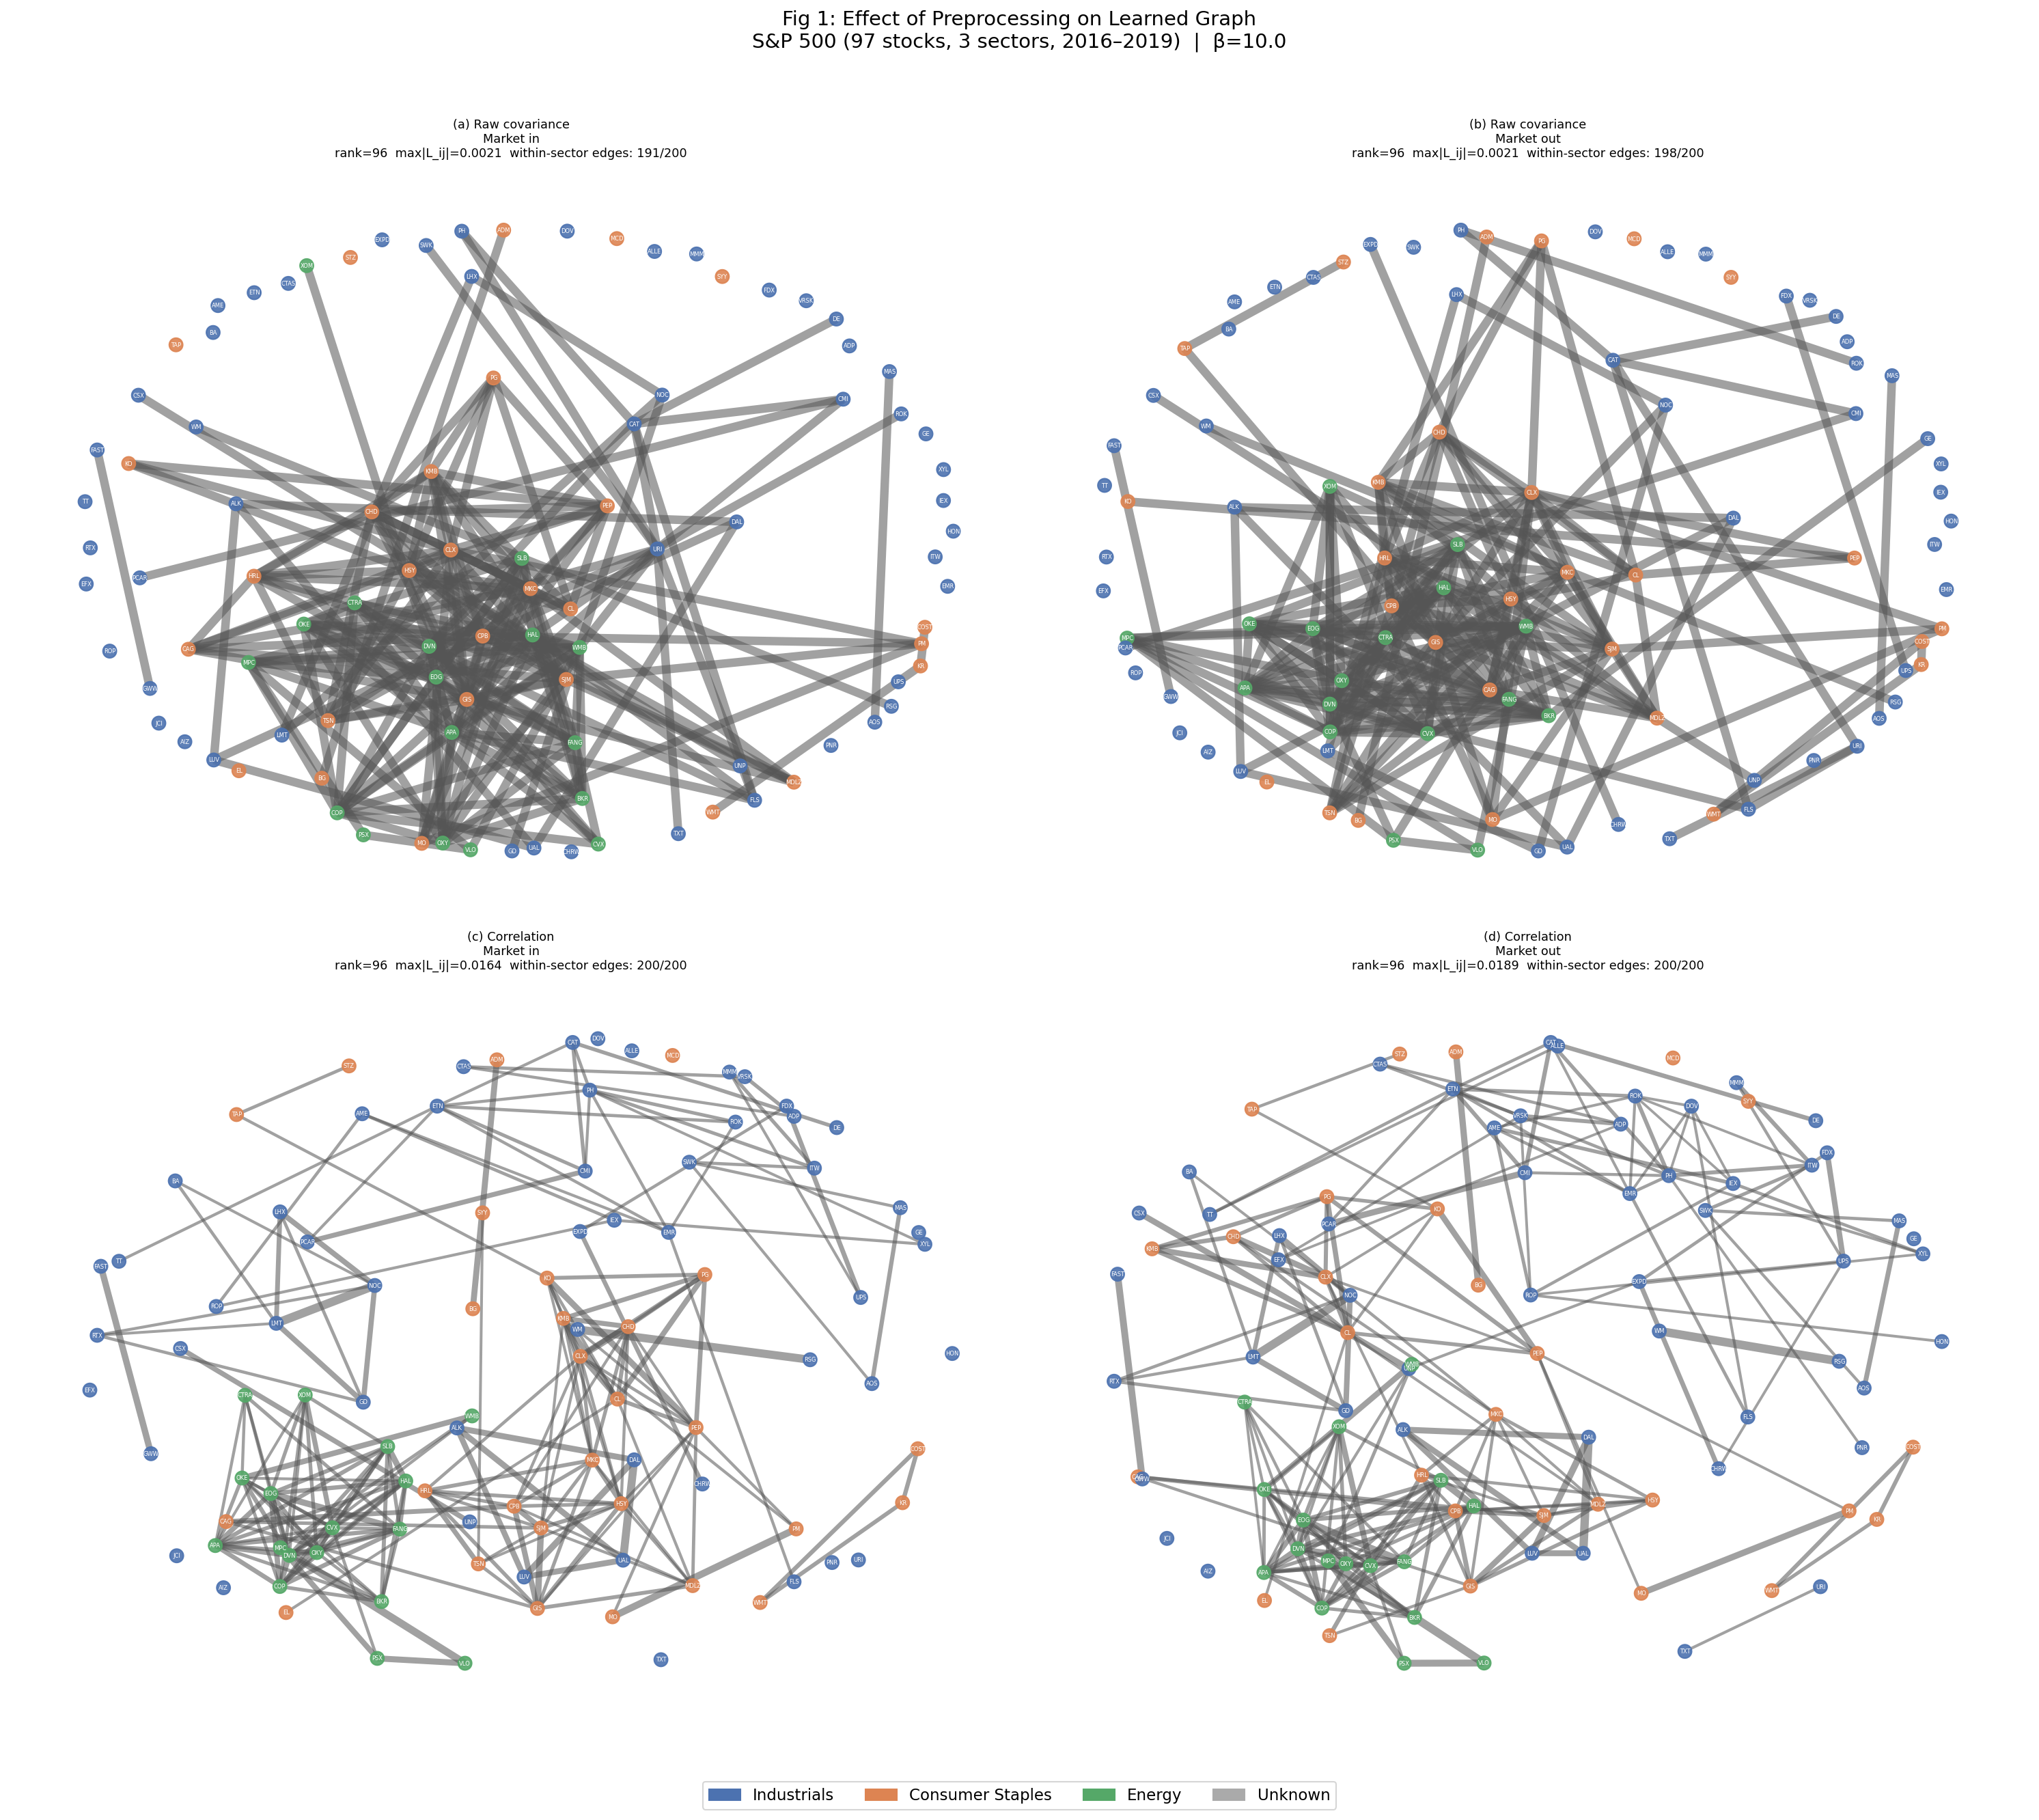

In [8]:
# Run experiment 1 (uses cached Laplacians if available — fast on re-run)
%run exp1_preprocessing.py
plt.close('all')  # prevent double display
display(Image('figures/fig1_preprocessing.png', width=980))

**How to read the figure.** Each panel is one learned graph. A node is a stock, coloured by sector (blue = Industrials, orange = Consumer Staples, green = Energy). An edge means the two stocks are *directly* linked in the fitted model — a conditional dependence, i.e. co-movement that is not explained away by the other 95 stocks — and thicker means stronger. To make the four panels visually comparable, each draws its top-200 edges with widths normalised within the panel; the subtitle counts how many drawn edges stay inside one sector.

**What it means.**
- **(a), (b) — covariance:** tangled hairballs with near-uniform edge weights (range ≈ 0.00206–0.00208 — the solver literally cannot discriminate between pairs). Sector colours are mixed together. This is the failure mode the paper warns about.
- **(c), (d) — correlation:** three clean clusters emerge; most strong edges connect stocks in the same sector, and the weight range widens ~2.6× (0.006–0.016), so pairs are actually ranked.
- **(c) ≈ (d):** removing the market factor changes almost nothing once returns are normalised — replicating the paper's conclusion that the best simple pipeline is *correlation with the market kept in*.


---

## 5. Experiment 2 — Degree Control: Algorithm 1 vs SGL (Fig 2)

**What this experiment is.** Same 97 stocks and the same correlation input. Both methods are asked for a $k=3$-component graph (ideally one component per sector) using a spectral penalty that pushes the 3 smallest Laplacian eigenvalues toward zero. The difference:

- **SGL** (Kumar et al. 2016): spectral penalty only, **no degree control** ($\beta = 10$).
- **Algorithm 1** (the paper's method): the same spectral idea **plus the constraint $\text{diag}(L) = 1$** — every node must carry exactly one unit of total edge weight. Solved with $\eta = 300$, $\beta = 0$, $\rho_{\text{degree}} = 100$.

Here "degree" means the total edge weight attached to a node, which is exactly the diagonal entry $L_{ii}$.

**What we are trying to show.** The paper's central methodological claim: without degree control the optimiser is free to starve nodes of edge weight, and the result is useless for clustering; with degree control every node must "spend" one unit of connection somewhere, so weight concentrates on the genuinely strong relationships and the sector structure emerges.

One caveat known in advance (documented as deviation D3): with our edge-weight solver, SGL's nodes *cannot* become exactly isolated — a fully disconnected node would send $\log\text{gdet}(L) \to -\infty$, and the solver is repelled from that boundary. So SGL's failure shows up as uniformly *tiny* degrees rather than the paper's true zero-degree nodes.


In [9]:
# SGL benchmark — no degree control
from solver.sgl_benchmark import sgl
display(Code(inspect.getsource(sgl), language='python'))

def sgl(S, beta=10.0, max_iter=1000, tol=1e-6):
    """
    SGL estimate of the graph Laplacian.

    Parameters
    ----------
    S        : (p, p) similarity / correlation matrix
    beta     : sparsity regulariser (paper uses 10)
    max_iter : max L-BFGS-B iterations
    tol      : convergence tolerance

    Returns
    -------
    L : (p, p) estimated Laplacian (may have isolated nodes)
    """
    return learn_laplacian(
        S,
        beta=beta,
        eta=0.0,
        V=None,
        degree_control=False,
        max_iter=max_iter,
        tol=tol,
    )

Loaded 97 stocks × 1005 trading days
Similarity matrix S: shape=(97, 97), diag range [1.000, 1.000]
Loaded SGL and Algorithm 1 from cache.

SGL: rank=96, isolated=0, λ_min=5.5511e-17, λ₂=0.0717
  P1=True  P2=True  PSD=True
  diag: min=0.1668  mean=0.1767  max=0.1853

Algorithm 1: rank=94, isolated=0, λ_min=-8.8827e-16, λ₂=0.0000
  P1=True  P2=True  PSD=True
  diag: min=0.9973  mean=1.0042  max=1.0071

Saved figures/fig2_kcomponent.png


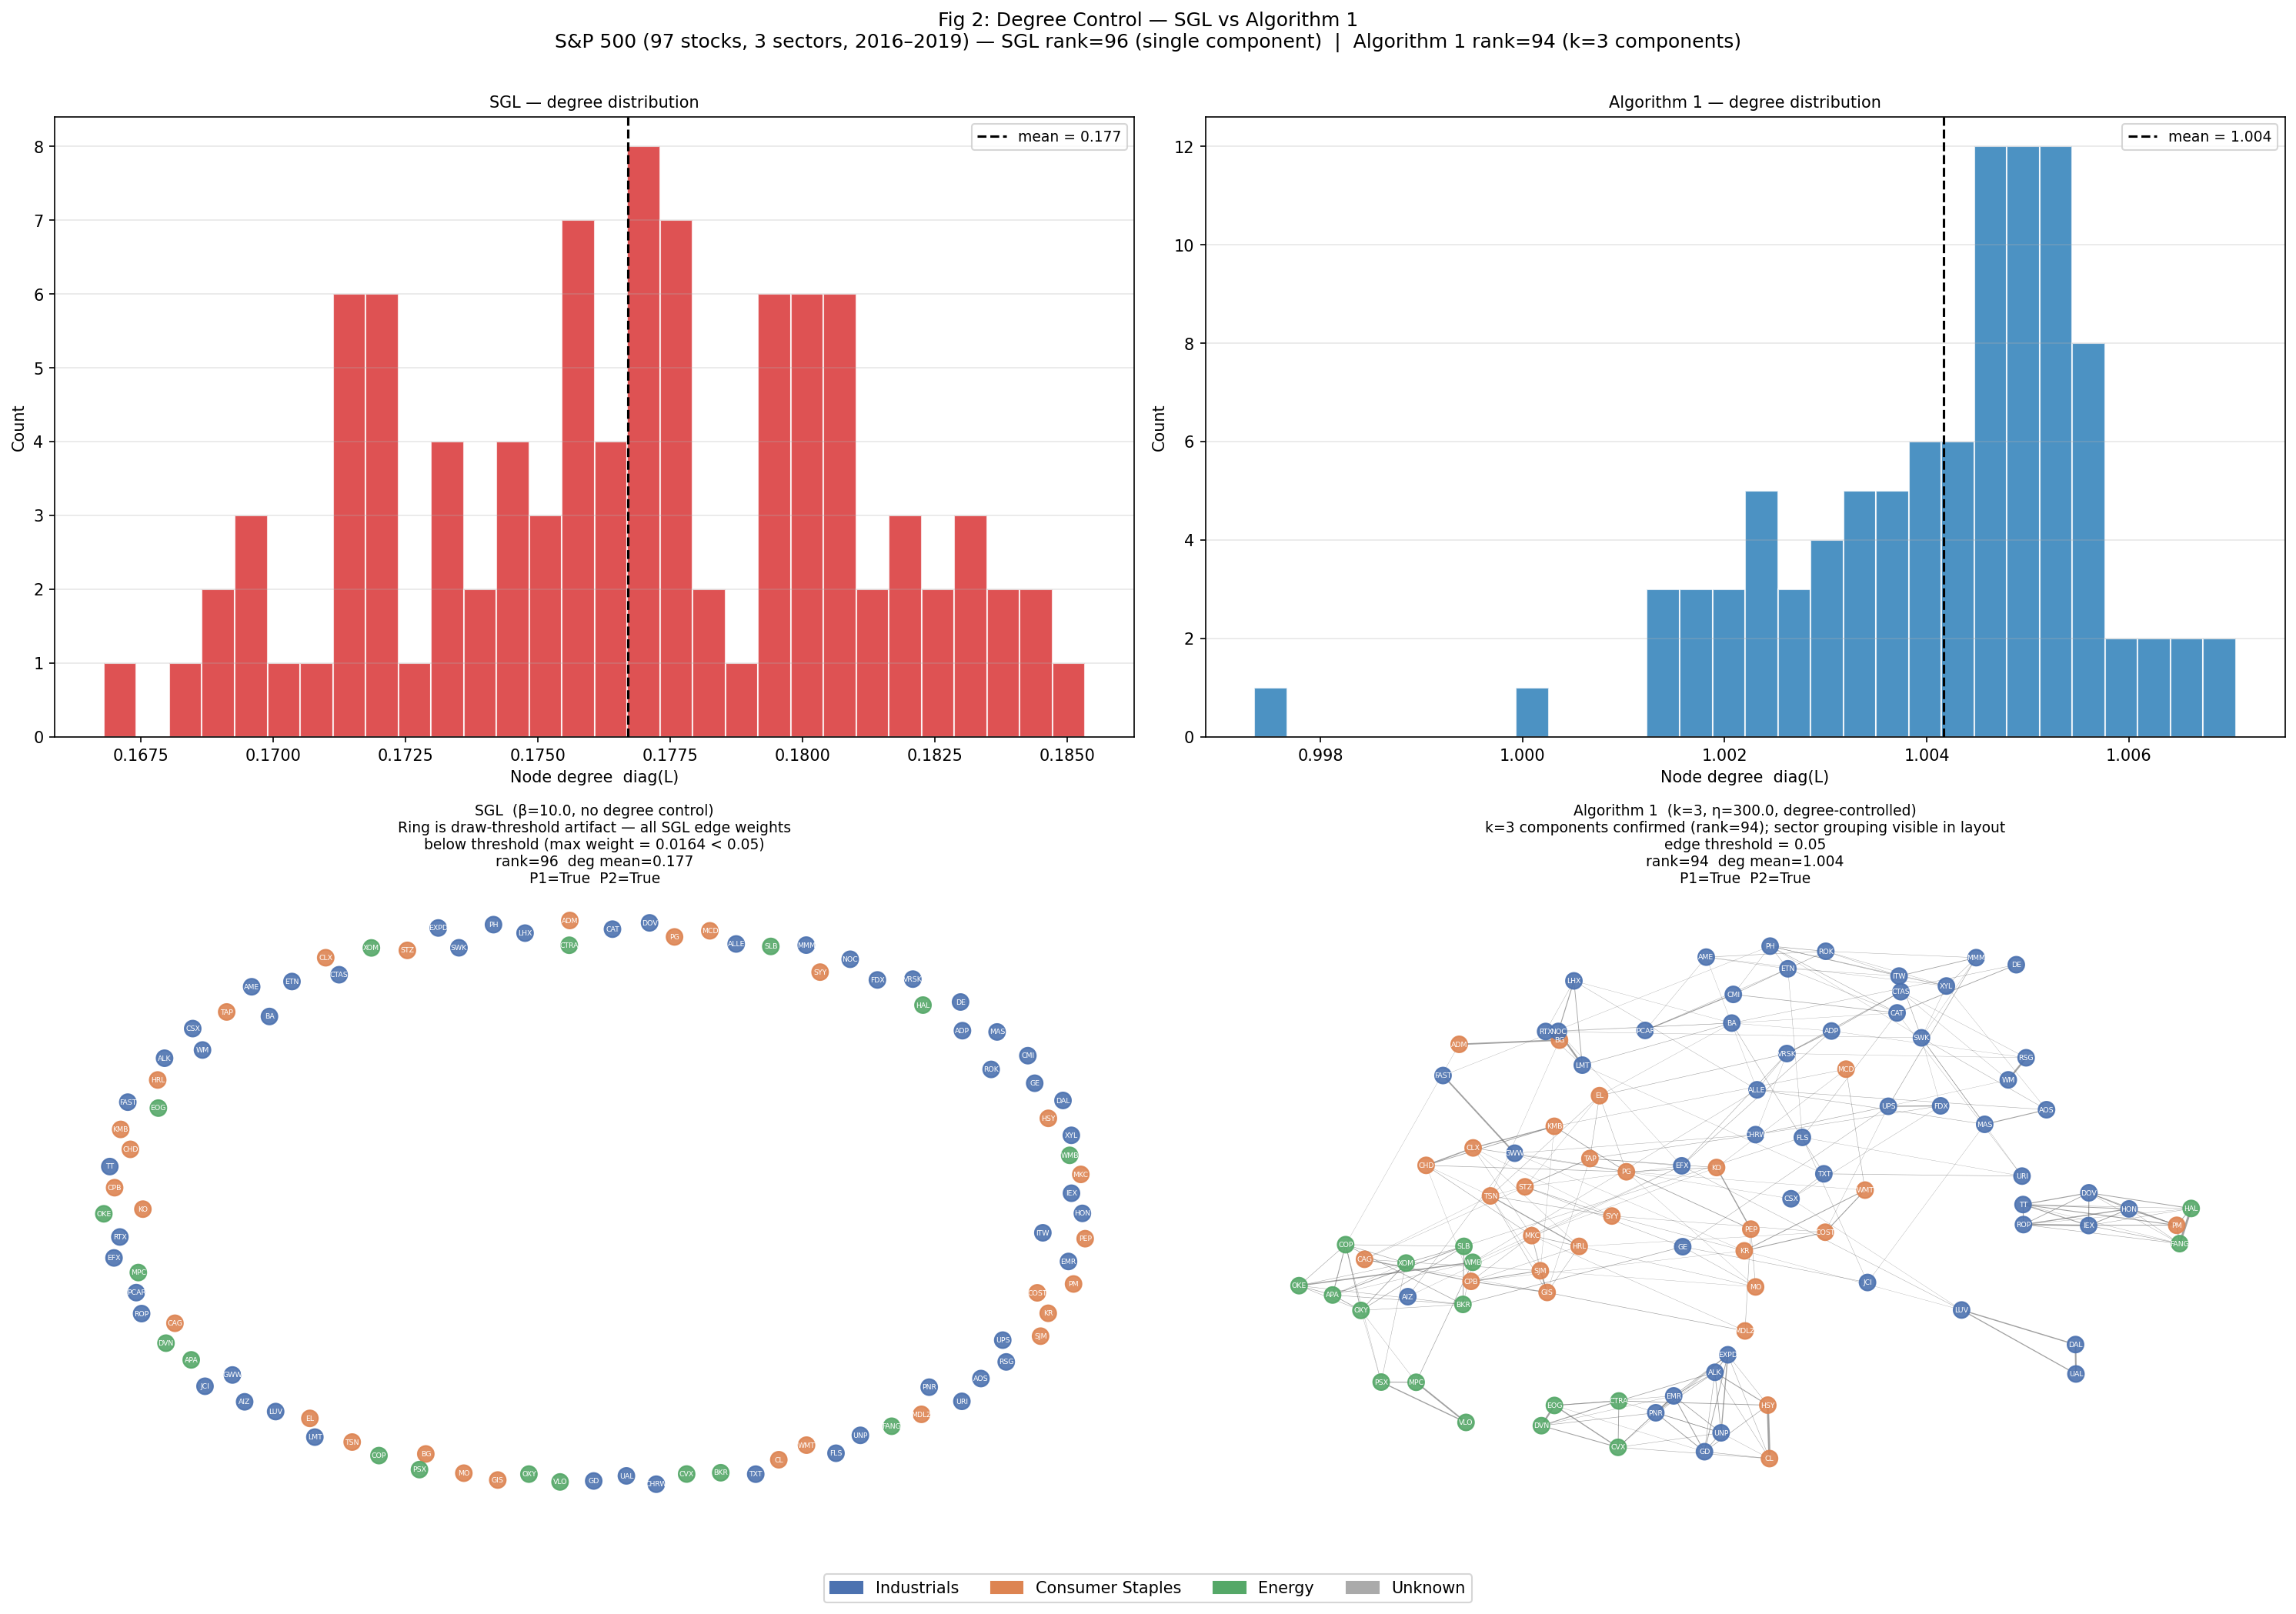

In [10]:
# Run experiment 2 (uses cached Laplacians if available)
%run exp2_kcomponent.py
plt.close('all')
display(Image('figures/fig2_kcomponent.png', width=980))

**How to read the figure.** Top row: histograms of node degree ($L_{ii}$) for each method — this is the quantitative comparison. Bottom row: the graphs themselves, drawing only edges with weight above 0.05, with a spring layout that pulls strongly connected nodes together.

**What it means.**
- **Top-left (SGL degrees):** all 97 values squeezed around 0.177 — small and uncontrolled. **Top-right (Algorithm 1 degrees):** pinned at ≈ 1.005 — the $\text{diag}(L)=1$ constraint is active and doing its job.
- **Bottom-left (SGL graph):** an empty ring. This is a **drawing artifact, not isolation**: SGL's largest edge weight is 0.0164, below the 0.05 draw threshold, so no edge qualifies to be drawn. Every node still has positive degree — the real finding is that *no relationship is strong*.
- **Bottom-right (Algorithm 1 graph):** strong within-sector edges and a genuinely 3-component graph — the Laplacian has rank $94 = 97 - 3$, i.e. exactly three zero eigenvalues, one per sector. (Getting there needed $\eta = 300$: at $\eta = 10$ the spectral penalty is only ~3% of the data term at $p = 97$ and the graph stays connected.)
- **Takeaway:** $\text{diag}(L) = 1$ is not a cosmetic normalisation. It is the ingredient that turns the same sparsity/spectral machinery from "everything weak" into interpretable sector structure.


---

## 6. Experiment 3 — Time-Varying Graphs and Algebraic Connectivity (Fig 3)

**What this experiment is.** We switch to the 7 FAAMUNG stocks (META, AAPL, AMZN, MSFT, UBER, NFLX, GOOGL), Jun 2019 – Jun 2020, and estimate a **new graph every trading day** from a rolling 30-day window (243 graphs in total). Estimation is *causal*: the graph for day $t$ uses only data up to day $t$ — no look-ahead. Consecutive graphs are tied together by a temporal penalty $(\delta/n_t)\,\|L_t - L_{t-1}\|_F^2$ with $\delta = 100$, so the network evolves smoothly instead of jumping with every window. (The penalty is implemented *exactly* in edge-weight space with warm-started solves; an earlier version had an inverted sign that repelled consecutive graphs and crushed the whole series — see dev_log §18.) No degree control here — the paper's time-varying problem doesn't include it — and $k=1$ keeps each graph connected.

From each graph we keep one number: the **algebraic connectivity** $\lambda_2$, the second-smallest eigenvalue of the Laplacian. Intuition: $\lambda_2$ measures how hard it is to cut the network into two pieces. Near 0 means there is a weak seam (some stock barely coupled to the rest); large means the stocks move as one tight system because their conditional correlations have risen.

**What we are trying to show.** That the sequence of learned graphs tracks market regimes — specifically the paper's claim that **connectivity rises in times of stress** (a crisis drags everything together) — and that our $\lambda_2$ lives on a scale comparable to the paper's (theirs spans ≈ 0.4–2.0, with $\tau = 1.0$ as the reference line).


In [11]:
from utils.graph_metrics import algebraic_connectivity
display(Code(inspect.getsource(algebraic_connectivity), language='python'))

def algebraic_connectivity(L, tol=1e-8):
    """
    Second smallest eigenvalue λ₂(L) — the Fiedler value.
    Measures how well-connected the graph is (0 = disconnected).
    """
    vals = eigh(L, eigvals_only=True)
    return float(vals[1]) if vals[1] > tol else 0.0

In [12]:
# Preview λ₂ series statistics from cache
lam2_cache = 'data/lam2_series.npy'
if os.path.exists(lam2_cache):
    lam2 = np.load(lam2_cache)
    print(f'λ₂ series: {len(lam2)} windows')
    print(f'  min    = {lam2.min():.4f}')
    print(f'  median = {np.median(lam2):.4f}')
    print(f'  max    = {lam2.max():.4f}')
    print(f'  τ=1.0 gate: {(lam2 >= 1.0).sum()}/{len(lam2)} windows at or above τ (cash days under the paper rule)')
else:
    print('Cache not found — will be computed when running exp3.')

λ₂ series: 243 windows
  min    = 0.6557
  median = 1.0705
  max    = 1.5011
  τ=1.0 gate: 140/243 windows at or above τ (cash days under the paper rule)


Loaded 243 λ₂ values from cache.
Re-running Algorithm 2 for network snapshots …

λ₂ stats: min=0.6557  median=1.0705  max=1.5011
Windows with λ₂ < τ=1.0: 103/243 (42.4%)

Saved figures/fig3_timevarying.png


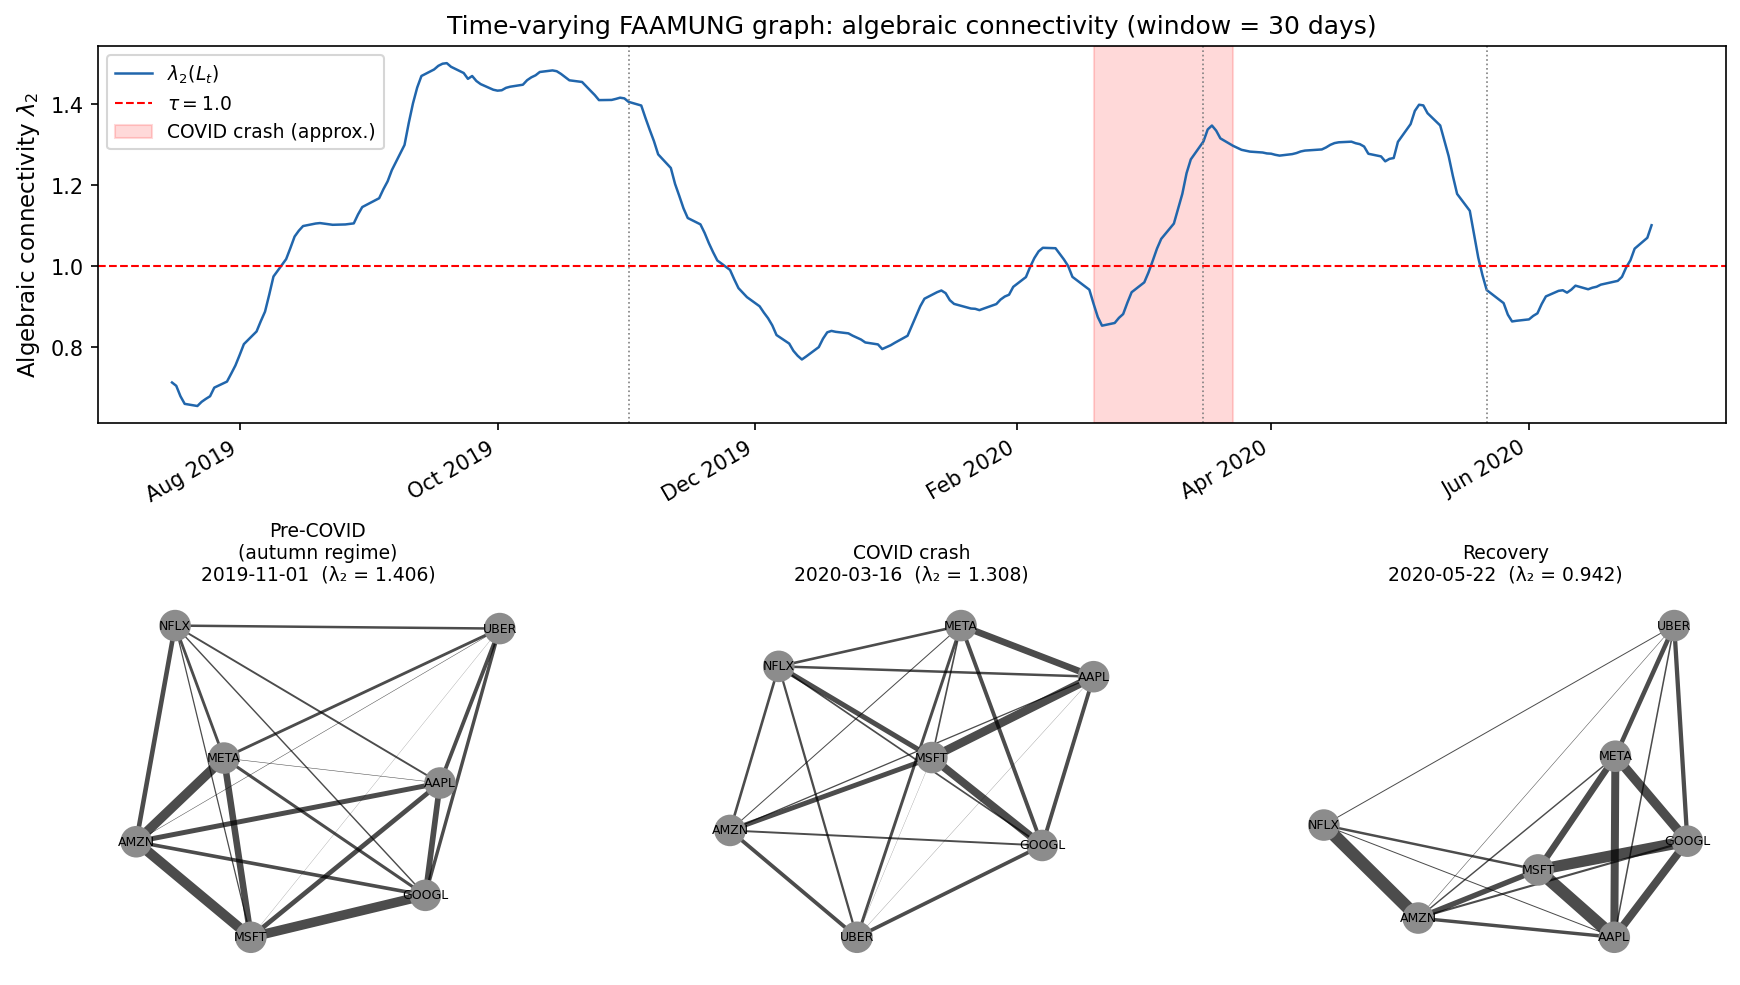

In [13]:
# Run experiment 3 (uses cached λ₂ series if available)
%run exp3_timevarying.py
plt.close('all')
display(Image('figures/fig3_timevarying.png', width=980))

**How to read the figure.** Top: $\lambda_2$ over time (blue), the paper's threshold $\tau = 1.0$ (red dashed), and the COVID crash window Feb 19 – Mar 23, 2020 (pink band). The dotted vertical lines mark the three snapshot dates shown below. Bottom: the actual network on those dates — edge thickness = strength of the conditional dependence.

**What it means.**
- The series has genuine regimes, and they line up with the paper's Fig 3b almost month by month: a climb through **autumn 2019** to ≈ 1.50 (the paper attributes its own September-2019 spike to impeachment-inquiry news), a calm **December trough** at 0.77, ≈ 0.9–1.0 through **Jan–Feb**, then a **rise through the crash** to 1.35 — connectivity going *up* under stress, as the mechanism predicts.
- **Snapshots:** 2019-11-01 ($\lambda_2 = 1.41$) is a dense web — note this "pre-COVID" date is *not* calm; it sits in the elevated autumn regime. 2020-03-16 ($\lambda_2 = 1.31$) is the crash: everything moving together. 2020-05-22 ($\lambda_2 = 0.94$) shows the web loosening as the market recovers.
- **One honest divergence that matters for the next experiment:** the paper's $\lambda_2$ spikes to ≈ 2.0 in March and collapses back below 1.0 in April; ours rises less and decays more slowly (still ≈ 1.3 through April). Same shape, different post-crash speed — this is precisely what breaks the trading ranking in Fig 4.


---

## 7. Experiment 4 — Connectivity-Gated Trading Strategy (Fig 4)

**What this experiment is.** A backtest over the paper's evaluation window (**Jun 2019 → 1 May 2020**) comparing two strategies on the FAAMUNG portfolio:

- **S1 (buy & hold):** equal weight in all 7 stocks, every day.
- **S2 (connectivity-gated):** the same portfolio, but only on days when the previous day's $\lambda_2 < \tau = 1.0$; otherwise sit in cash (zero return). High connectivity = stress = stay out.

The signal is causal — $\lambda_2$ from the window ending day $t$ sets the position for day $t+1$ — and $\tau = 1.0$ is the paper's threshold used as-is. With our $\lambda_2$ ranging 0.66–1.50 it genuinely bites: S2 is invested on 79 of 201 days.

**What we are trying to show.** Whether the stress signal has *timing value*: can a strategy that steps aside when the network tightens avoid the crash and beat buy-and-hold, as the paper reports? Two honesty devices run before the plot:
1. a **diagnostic** checking which direction the data actually supports (does $\lambda_2$ rise going into the crash?), and
2. a **table of both rule directions × both τ choices**, so a winning cell cannot be quietly cherry-picked.

The rule direction is chosen by the diagnostic, never by the P&L.


In [14]:
# Show how the trading signal is constructed (the investment logic from exp4)
import exp4_trading
display(Code(inspect.getsource(exp4_trading.main), language='python'))

def main():
    df = pd.read_csv(
        os.path.join("data", "faamung.csv"), index_col=0, parse_dates=True
    )
    returns = df.values  # (T, 7)
    dates_idx = df.index
    T = returns.shape[0]

    lam2, day_indices = load_or_compute(returns)

    # Truncate to the paper's evaluation period: keep signals whose invest
    # day (t+1, causal) falls on or before END_DATE.
    keep = [
        i for i, t in enumerate(day_indices)
        if t + 1 < T and dates_idx[t + 1] <= END_DATE
    ]
    lam2 = lam2[keep]
    day_indices = [day_indices[i] for i in keep]
    print(f"Truncated to paper period: {len(day_indices)} signal days "
          f"(last invest day {dates_idx[day_indices[-1] + 1].date()}).")

    # Equal-weight portfolio daily log-return
    port_ret = returns.mean(axis=1)  # (T,)

    # Diagnostic: confirm signal direction before applying rule
    diagnose_signal(lam2, day_indices, dates_idx, port_ret)

    # Align: signal on day t (end of window) → invest on day t+1 (causal)
    invest_dates = []
    s1_rets = []

    for i, t in enumerate(day_indices):
        next_t = t + 1
        if next_t >= T:
            break
        invest_dates.append(dates_idx[next_t])
        s1_rets.append(port_ret[next_t])

    s1_rets = np.array(s1_rets)
    invest_dates = pd.DatetimeIndex(invest_dates)

    # S2: paper direction — invest when λ₂ < TAU (exit when high = stressed market)
    s2_rets = compute_s2(lam2, s1_rets, invest_high=False, tau=TAU)

    # Cumulative log-return (starts at 0)
    s1_cum = np.concatenate([[0.0], np.cumsum(s1_rets)])
    s2_cum = np.concatenate([[0.0], np.cumsum(s2_rets)])
    plot_dates = pd.DatetimeIndex([dates_idx[day_indices[0]]] + list(invest_dates))

    # ── Diagnostics ───────────────────────────────────────────────────────────
    print(f"\nλ₂  min={lam2.min():.4f}  median={np.median(lam2):.4f}  max={lam2.max():.4f}")
    invest_days = int((lam2[: len(s1_rets)] < TAU).sum())
    total_days = len(s1_rets)
    print(f"S2 invests {invest_days}/{total_days} days ({100*invest_days/total_days:.1f}%)")
    print(f"S1 final cumulative log-return: {s1_cum[-1]:.4f}")
    print(f"S2 final cumulative log-return: {s2_cum[-1]:.4f}")
    print(f"S2 beats S1: {s2_cum[-1] > s1_cum[-1]}")

    # Print the both-directions × both-τ table
    print_table(lam2, s1_rets, s1_cum)

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 5))

    # S2 coincides exactly with S1 when τ never gates, so draw S1 solid and
    # S2 dashed on top — the red shows through the dash gaps.
    ax.plot(plot_dates, s1_cum, color="#d62728", linewidth=2.4,
            label="S1: Buy & Hold (equal-weight FAAMUNG)")
    s2_label = rf"S2: Invest when $\lambda_2 < \tau={TAU:.2f}$ (paper direction: cash when stressed)"
    if np.array_equal(s1_cum, s2_cum):
        s2_label += " — coincides with S1 ($\\tau$ never gates)"
    ax.plot(plot_dates, s2_cum, color="#1f77b4", linewidth=1.6,
            linestyle=(0, (4, 3)), label=s2_label)

    # Shade COVID crash
    ax.axvspan(
        pd.Timestamp("2020-02-19"), pd.Timestamp("2020-03-23"),
        alpha=0.12, color="red", label="COVID crash (approx.)"
    )
    ax.axhline(0.0, color="black", linewidth=0.6, linestyle=":")

    ax.set_xlabel("Date", fontsize=11)
    ax.set_ylabel("Cumulative log-return", fontsize=11)
    ax.set_title(
        f"Trading strategy: S1 (buy & hold) vs S2 (connectivity-gated, $\\lambda_2 < \\tau={TAU:.2f}$)"
        " — Jun 2019 to May 2020 (paper period)",
        fontsize=12,
    )
    ax.legend(fontsize=9, loc="upper left")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

    # Annotate final values
    ax.annotate(
        f"S1: {s1_cum[-1]:.3f}",
        xy=(plot_dates[-1], s1_cum[-1]),
        xytext=(-55, 8),
        textcoords="offset points",
        f

Loaded 243 λ₂ values from cache.
Truncated to paper period: 201 signal days (last invest day 2020-05-01).

=== Fix 1 Diagnostic: λ₂ signal direction ===
  mean(λ₂ INSIDE  COVID 2020-02-19→2020-03-23) = 1.0847  (n=24)
  mean(λ₂ OUTSIDE COVID window, global)         = 1.1139  (n=177)
  mean(λ₂ 60 days PRE-crash, local baseline)    = 0.9030
  Corr(λ₂, fwd-5-day portfolio return)          = +0.1366
  Corr(λ₂, fwd-5-day worst-day return)          = -0.0529
  VERDICT: PAPER DIRECTION (local): λ₂ RISES entering the crash (0.903 → 1.085) → invest when λ₂ < τ
  (Global outside-mean exceeds the crash mean only because the
   autumn-2019 regime is elevated — same shape as paper Fig 3b.)

λ₂  min=0.6557  median=1.1036  max=1.5011
S2 invests 79/201 days (39.3%)
S1 final cumulative log-return: 0.0779
S2 final cumulative log-return: -0.0111
S2 beats S1: False

=== Both-directions × both-τ table ===
  S1 (buy & hold) final cumulative log-return: 0.0779

  Rule                                          

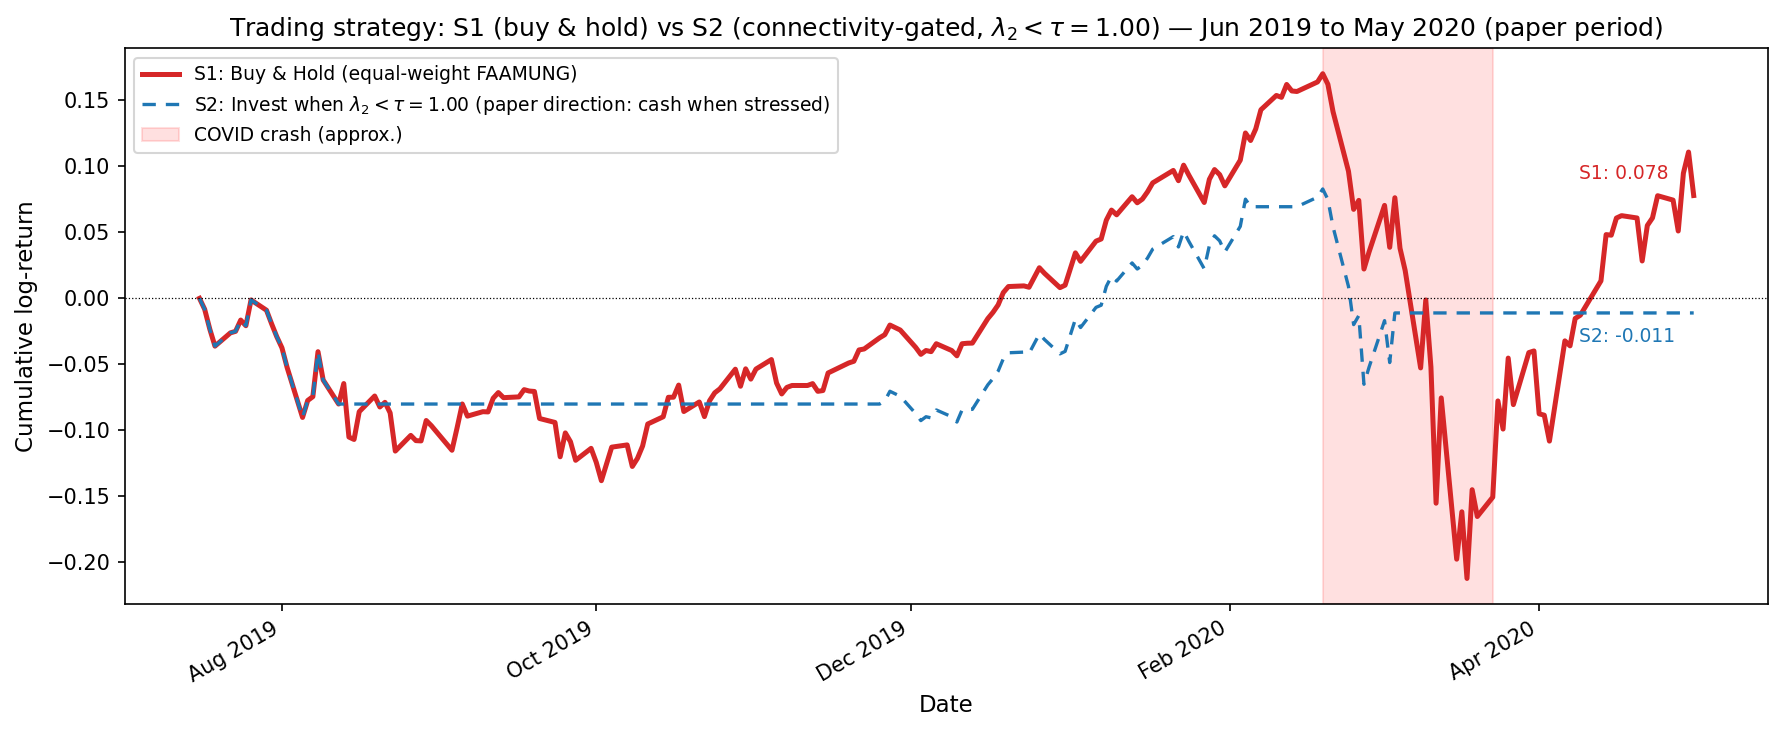

In [15]:
# Run experiment 4 (fast — reuses cached λ₂ series)
%run exp4_trading.py
plt.close('all')
display(Image('figures/fig4_trading.png', width=980))

**How to read the figure.** Cumulative log-return of each strategy, starting at 0. Solid red = S1 (always invested); dashed blue = S2. Flat stretches of the blue line are days S2 sits in cash. Pink band = the COVID crash.

**What it means.**
- **The diagnostic supports the paper's direction:** $\lambda_2$ rises from a 0.90 pre-crash baseline to 1.08 inside the crash window (1.35 at the peak), so "exit when $\lambda_2 \ge 1$" is the mechanism-consistent rule. (The *global* average outside the crash is slightly higher than inside only because autumn 2019 was an elevated regime — the paper's own series has the same feature, so this is a known confounder, not a contradiction.)
- **What replicates:** S2 is in cash through the elevated autumn-2019 regime (the paper's S2 is likewise flat then), invests through the calm December–February stretch, and steps out as $\lambda_2$ crosses 1.0 in late February — so it stays **flat through the entire crash while S1 falls to $-0.21$**. The crash-avoidance mechanism works exactly as in the paper.
- **What does not:** in the paper, $\lambda_2$ drops back below 1.0 in April, so its S2 re-enters and rides the rebound, finishing ahead of S1 (≈ 1.35 vs ≈ 1.12). Our $\lambda_2$ stays ≈ 1.3 through April, so S2 remains in cash during the early rebound and finishes at $\mathbf{-0.011}$ vs S1's $\mathbf{+0.078}$: **S2 does not beat S1 here.**
- **The τ-table keeps us honest:** the paper rule loses at both τ choices; only the *anti-paper* rule (invest when $\lambda_2 \ge \tau$) wins on this sample — an in-sample artifact, not a validation of anything.
- **Verdict:** mechanism ✓ (connectivity rises in crisis), crash-avoidance ✓, final P&L ranking ✗. The gap traces to how fast the *estimated* connectivity decays after the crash — a solver property, not a flaw in the strategy logic.


---

## 8. Summary

Three of four figures replicate cleanly; Fig 4 replicates the mechanism and the crash-avoidance but not the final P&L ranking:

| Figure | Paper's claim | Our result |
|--------|--------------|------------|
| **Fig 1** | Correlation-based similarity gives cleaner sector graphs than covariance | ✓ Panels (c/d) show visible sector clustering; (a/b) are tangled |
| **Fig 2** | Degree control stabilises node degrees in graph learning | ✓ SGL degrees uncontrolled (mean 0.177); Algorithm 1 controlled (mean 1.005). SGL ring is draw-threshold artifact (max weight 0.016 < 0.05); Algorithm 1 achieves true $k=3$ (rank 94) at $\eta=300$ |
| **Fig 3** | $\lambda_2(L_t)$ tracks market regimes | ✓ $\lambda_2 \in [0.66, 1.50]$ with the paper's regime structure: autumn-2019 elevation, December trough, rise through the COVID crash to 1.35 |
| **Fig 4** | $\lambda_2$-gated strategy (S2) outperforms buy-and-hold (S1) | Partial (evaluated on the paper's window, Jun 2019 – 1 May 2020): S2 dodges the crash exactly as in the paper (flat while S1 falls to $-0.21$), but our $\lambda_2$ decays slowly post-crash → S2 misses the early rebound: S2 $=-0.011$ < S1 $=+0.078$ |

### Implementation notes

- The paper's Problem 1 is solved via **L-BFGS-B on edge weights** rather than ADMM, exploiting the signed incidence matrix parameterization.
- The degree control penalty (Algorithm 1 only) is implemented as a quadratic augmentation: $\frac{\rho}{2}\|\text{diag}(L) - \mathbf{1}\|^2$. Algorithm 2 (Figs 3/4) uses **uncontrolled** Laplacians per the paper's Problem 11.
- The temporal penalty $\delta\|L_t - L_{t-1}\|_F^2$ is implemented **exactly** in edge-weight space (a plain quadratic with closed-form gradient) with warm-started windows. An earlier linearisation had an inverted sign that repelled consecutive graphs and crushed the $\lambda_2$ scale — see dev_log §18.
- The paper's $\tau = 1.0$ is used as-is and genuinely gates: 79/201 invested days over the paper's evaluation window (backtest truncated at 2020-05-01 to match the paper's Fig 4).
- All expensive solves are cached to `.npy` files in `data/` so subsequent notebook runs are fast.
